# AI-assisted RAPID localization and meeting figures

This notebook converts path-level AI scores and baseline-to-magnet feature changes into 2D RAPID maps.

It compares:

- raw MLP probabilities;
- raw logistic-regression probabilities;
- robust feature-change RAPID, which is used as the primary localization result because it suppresses saturated classifier probabilities.

Ground truth: magnet centre `(y,x)=(215,150) mm`.

In [1]:
from pathlib import Path
import sys, numpy as np, pandas as pd, matplotlib.pyplot as plt

PROJECT_DIR=Path.cwd()
if str(PROJECT_DIR) not in sys.path: sys.path.insert(0,str(PROJECT_DIR))
from dl_settings import *
from dl_utils import *

PZT_DIR=DATASET_ROOT/PZT_FOLDER
RESULTS_ROOT=ensure_dir(PROJECT_DIR/RESULTS_FOLDER)
FIG_DIR=ensure_dir(PROJECT_DIR/"figures")
OUT=ensure_dir(RESULTS_ROOT/"12_ai_assisted_rapid")
PRED_CSV=RESULTS_ROOT/"10_pzt_mlp_classifier"/"path_level_oof_predictions.csv"
FEATURE_PATH=find_feature_file(PZT_DIR,FEATURE_FILE_CANDIDATES)

pred=pd.read_csv(PRED_CSV)
damage_pred=pred[pred.state=="magnet"].copy()
print("Notebook 12 does not train a neural network; it uses saved path-level predictions and the original PZT feature changes.")
print("Prediction input file:",PRED_CSV)
print("Feature input file:",FEATURE_PATH)
print("Results folder:",OUT)
print("Figures folder:",FIG_DIR)
display(pd.DataFrame([{"input_table":"path-level predictions","shape":pred.shape,"magnet_rows":len(damage_pred),"nan_count":int(pred.isna().sum().sum())}]))
display(damage_pred.head())

Notebook 12 does not train a neural network; it uses saved path-level predictions and the original PZT feature changes.
Prediction input file: /home/awais/Desktop/Awais Work 2026/KAIST Work/Team 1/KAIST Data/20260611_Data2/AwsGPT_Codes/July2_DL_Meeting_work/paper5_dl_results/10_pzt_mlp_classifier/path_level_oof_predictions.csv
Feature input file: /home/awais/Desktop/Awais Work 2026/KAIST Work/Team 1/KAIST Data/20260611_Data2/260609_pzt_network/physics_features_phase1_bpf.npz
Results folder: /home/awais/Desktop/Awais Work 2026/KAIST Work/Team 1/KAIST Data/20260611_Data2/AwsGPT_Codes/July2_DL_Meeting_work/paper5_dl_results/12_ai_assisted_rapid
Figures folder: /home/awais/Desktop/Awais Work 2026/KAIST Work/Team 1/KAIST Data/20260611_Data2/AwsGPT_Codes/July2_DL_Meeting_work/figures


,input_table,shape,magnet_rows,nan_count
0,path-level predictions,"(60, 7)",30,0


,src,rx,state,label,prob_damage_mlp,prob_damage_logreg,reciprocal_group
30,1,2,magnet,1,0.999999,0.238922,0
31,1,3,magnet,1,0.768066,0.537177,1
32,1,4,magnet,1,0.402123,0.401764,2
33,1,5,magnet,1,0.998464,0.331882,3
34,1,6,magnet,1,1.000000,0.354441,4


In [2]:
pred["pair_a"]=pred[["src","rx"]].min(axis=1)
pred["pair_b"]=pred[["src","rx"]].max(axis=1)
damage_pred=pred[pred.state=="magnet"].copy()

pair_prob=(
    pred.groupby(["pair_a","pair_b","state"],as_index=False)
    .agg(
        prob_damage_mlp=("prob_damage_mlp","mean"),
        prob_damage_logreg=("prob_damage_logreg","mean")
    )
    .pivot(index=["pair_a","pair_b"],columns="state")
)
pair_prob.columns=[f"{metric}_{state}" for metric,state in pair_prob.columns]
pair_prob=pair_prob.reset_index()
pair_prob["prob_damage_mlp"]=pair_prob["prob_damage_mlp_magnet"]
pair_prob["prob_damage_logreg"]=pair_prob["prob_damage_logreg_magnet"]
pair_prob["prob_delta_mlp"]=(pair_prob["prob_damage_mlp_magnet"]-pair_prob["prob_damage_mlp_baseline"]).clip(lower=0)
pair_prob["prob_delta_logreg"]=(pair_prob["prob_damage_logreg_magnet"]-pair_prob["prob_damage_logreg_baseline"]).clip(lower=0)

def row_median_impute(v):
    v=np.asarray(v,dtype=float)
    finite=np.isfinite(v)
    fill=np.nanmedian(v[finite]) if finite.any() else 0.0
    return np.where(finite,v,fill)

with np.load(FEATURE_PATH,allow_pickle=False) as z:
    pair_idx=normalize_pair_idx(z["pair_idx"])
    Xb=flatten_samples(to_sample_first(z["X_pzt_baseline"],len(pair_idx)))
    Xm=flatten_samples(to_sample_first(z["X_pzt_damage"],len(pair_idx)))

feature_rows=[]
for i,(src,rx) in enumerate(pair_idx):
    xb=row_median_impute(Xb[i])
    xm=row_median_impute(Xm[i])
    diff=xm-xb
    feature_rows.append({
        "pair_a":min(int(src),int(rx)),
        "pair_b":max(int(src),int(rx)),
        "feature_l2_rel":np.linalg.norm(diff)/(np.linalg.norm(xb)+1e-9),
        "feature_l1_rel":np.sum(np.abs(diff))/(np.sum(np.abs(xb))+1e-9),
        "feature_max_rel":np.max(np.abs(diff))/(np.max(np.abs(xb))+1e-9),
        "feature_cosine_distance":1.0-np.dot(xb,xm)/(np.linalg.norm(xb)*np.linalg.norm(xm)+1e-9),
    })

pair_feature=pd.DataFrame(feature_rows).groupby(["pair_a","pair_b"],as_index=False).mean()
pair_prob=pair_prob.merge(pair_feature,on=["pair_a","pair_b"],how="left")

# Primary robust localization input. It uses the physical baseline-to-magnet change
# and avoids the saturated MLP probabilities that caused the false far-field peak.
pair_prob["damage_index_feature"]=pair_prob["feature_max_rel"]

display(pair_prob)
pair_prob.to_csv(OUT/"reciprocal_averaged_probabilities.csv",index=False)

,pair_a,pair_b,prob_damage_mlp_baseline,prob_damage_mlp_magnet,prob_damage_logreg_baseline,prob_damage_logreg_magnet,prob_damage_mlp,prob_damage_logreg,prob_delta_mlp,prob_delta_logreg,feature_l2_rel,feature_l1_rel,feature_max_rel,feature_cosine_distance,damage_index_feature
0,1,2,0.015597,0.998045,0.461246,0.293039,0.998045,0.293039,0.982448,0.000000,0.208317,0.181901,0.140891,0.022006,0.140891
1,1,3,0.263533,0.883929,0.531623,0.483153,0.883929,0.483153,0.620396,0.000000,0.306259,0.230738,0.249911,0.048272,0.249911
2,1,4,0.138639,0.360429,0.396243,0.400777,0.360429,0.400777,0.221790,0.004534,0.181074,0.160516,0.127316,0.016470,0.127316
3,1,5,0.040581,0.997388,0.435906,0.353124,0.997388,0.353124,0.956807,0.000000,0.302577,0.228787,0.215809,0.046907,0.215809
4,1,6,0.057162,1.000000,0.535870,0.545710,1.000000,0.545710,0.942838,0.009841,0.208556,0.181284,0.141472,0.022351,0.141472
5,2,3,0.059774,0.662877,0.512156,0.495152,0.662877,0.495152,0.603103,0.000000,0.221166,0.192154,0.149819,0.024899,0.149819
6,2,4,0.027157,0.992194,0.508826,0.703091,0.992194,0.703091,0.965037,0.194265,0.342963,0.261148,0.294045,0.060424,0.294045
7,2,5,0.032621,0.305432,0.315527,0.336352,0.305432,0.336352,0.272812,0.020825,0.237906,0.200138,0.164904,0.028710,0.164904
8,2,6,0.008222,1.000000,0.406351,0.752351,1.000000,0.752351,0.991778,0.346000,0.154501,0.145625,0.106855,0.012011,0.106855
9,3,4,0.094593,0.742864,0.509410,0.544901,0.742864,0.544901,0.648271,0.035491,0.203237,0.174817,0.140000,0.021143,0.140000


In [3]:
PZT_EXCLUSION_RADIUS_MM=20.0

def pzt_exclusion_mask(xx,yy,radius_mm=PZT_EXCLUSION_RADIUS_MM):
    mask=np.zeros_like(xx,dtype=bool)
    for py,px in PZT_POSITIONS_YX_MM.values():
        mask |= np.hypot(xx-px,yy-py) <= radius_mm
    return mask

def nearest_pzt_distance(y_mm,x_mm):
    return min(float(np.hypot(x_mm-px,y_mm-py)) for py,px in PZT_POSITIONS_YX_MM.values())

def normalized_weights(values):
    values=np.asarray(values,dtype=float)
    values=np.nan_to_num(values,nan=0.0,posinf=0.0,neginf=0.0)
    values=values-values.min()
    vmax=values.max()
    return values/vmax if vmax>0 else values

def make_rapid(weights_col,beta=1.08,step_mm=1.0,pzt_exclusion_radius_mm=PZT_EXCLUSION_RADIUS_MM,normalize_input=False):
    y=np.arange(0,300+step_mm,step_mm)
    x=np.arange(0,300+step_mm,step_mm)
    xx,yy=np.meshgrid(x,y)
    img=np.zeros_like(xx,dtype=float)
    raw_weights=pair_prob[weights_col].to_numpy(dtype=float)
    weights=normalized_weights(raw_weights) if normalize_input else np.nan_to_num(raw_weights,nan=0.0,posinf=0.0,neginf=0.0)

    for weight,(_,r) in zip(weights,pair_prob.iterrows()):
        a,b=int(r.pair_a),int(r.pair_b)
        img += weight*rapid_sensitivity(
            xx,yy,PZT_POSITIONS_YX_MM[a],PZT_POSITIONS_YX_MM[b],beta=beta
        )

    img=minmax(img)
    peak_img=img.copy()
    peak_img[pzt_exclusion_mask(xx,yy,pzt_exclusion_radius_mm)]=np.nan
    if np.all(np.isnan(peak_img)):
        raise ValueError("PZT exclusion mask removed all candidate peak pixels")
    iy,ix=np.unravel_index(np.nanargmax(peak_img),peak_img.shape)
    py,px=float(y[iy]),float(x[ix])
    return x,y,img,peak_img,py,px,nearest_pzt_distance(py,px)

true_y,true_x=MAGNET_YX_MM
rows=[]; maps={}

for name,col,role,normalize_input in [
    ("MLP probability diagnostic","prob_damage_mlp","diagnostic",False),
    ("Logistic probability diagnostic","prob_damage_logreg","diagnostic",False),
    ("Robust feature-change RAPID","damage_index_feature","primary",True),
]:
    x,y,img,peak_img,py,px,nearest_pzt_dist=make_rapid(col,normalize_input=normalize_input)
    err=float(np.hypot(px-true_x,py-true_y))
    rows.append({
        "method":name,
        "role":role,
        "predicted_y_mm":py,
        "predicted_x_mm":px,
        "localization_error_mm":err,
        "nearest_pzt_distance_mm":nearest_pzt_dist,
        "pzt_exclusion_radius_mm":PZT_EXCLUSION_RADIUS_MM
    })
    maps[name]=(x,y,img,peak_img,py,px,err,nearest_pzt_dist)

summary=pd.DataFrame(rows)
display(summary)


,method,role,predicted_y_mm,predicted_x_mm,localization_error_mm,nearest_pzt_distance_mm,pzt_exclusion_radius_mm
0,MLP probability diagnostic,diagnostic,78.0,192.0,143.293405,41.645078,20.0
1,Logistic probability diagnostic,diagnostic,218.0,110.0,40.112342,46.111956,20.0
2,Robust feature-change RAPID,primary,216.0,153.0,3.162278,72.974739,20.0


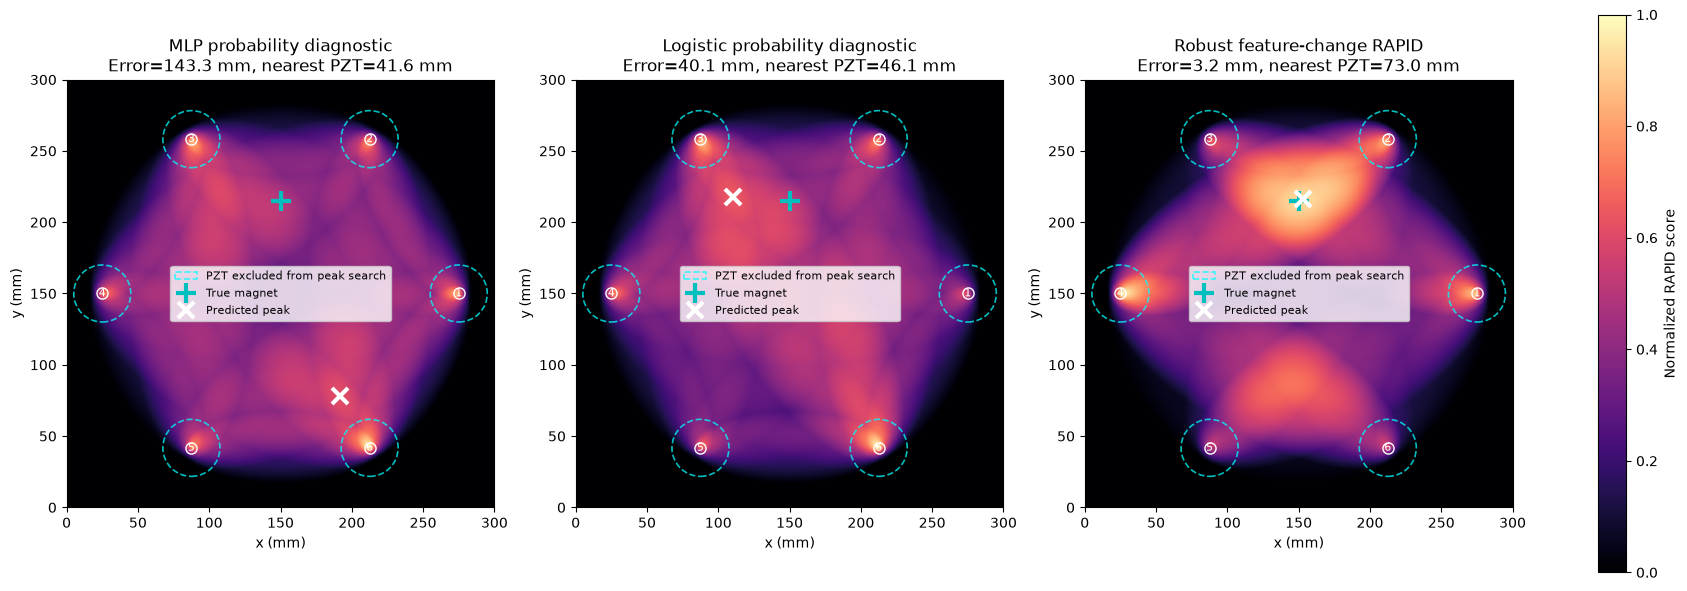

In [4]:
fig,axes=plt.subplots(1,len(maps),figsize=(5.6*len(maps),5.8),constrained_layout=True)
axes=np.atleast_1d(axes)

for ax,(name,(x,y,img,peak_img,py,px,err,nearest_pzt_dist)) in zip(axes,maps.items()):
    im=ax.imshow(img,origin="lower",extent=[0,300,0,300],
                 cmap="magma",vmin=0,vmax=1,aspect="equal")
    exclusion_label="PZT excluded from peak search"
    for p,(yy,xx) in PZT_POSITIONS_YX_MM.items():
        ax.add_patch(plt.Circle((xx,yy),PZT_EXCLUSION_RADIUS_MM,fill=False,
                                ec="cyan",ls="--",lw=1.2,alpha=.75,
                                label=exclusion_label if p==1 else None))
        ax.plot(xx,yy,"wo",mfc="none",ms=8)
        ax.text(xx,yy,str(p),color="white",ha="center",va="center",fontsize=8)
    ax.plot(true_x,true_y,"c+",ms=14,mew=3,label="True magnet")
    ax.plot(px,py,"wx",ms=12,mew=3,label="Predicted peak")
    ax.set_title(f"{name}\nError={err:.1f} mm, nearest PZT={nearest_pzt_dist:.1f} mm")
    ax.set_xlabel("x (mm)"); ax.set_ylabel("y (mm)")
    ax.legend(fontsize=8)

fig.colorbar(im,ax=axes,label="Normalized RAPID score")
fig.savefig(FIG_DIR/"12_Figure_AI_assisted_RAPID_comparison.png",dpi=300,bbox_inches="tight")
plt.show()

In [5]:
classifier_summary=pd.read_csv(
    RESULTS_ROOT/"10_pzt_mlp_classifier"/"model_summary.csv"
)
cross_modal_metrics=pd.read_csv(
    RESULTS_ROOT/"11_cross_modal_alignment"/"cross_modal_fold_metrics.csv"
)

mlp_auc=classifier_summary.loc[classifier_summary.model=="Small MLP","auc"].iloc[0]
top1=cross_modal_metrics.top1_retrieval_accuracy.mean()
rapid_error=summary.loc[summary.role=="primary","localization_error_mm"].iloc[0]

meeting_table=pd.DataFrame({
    "Demonstration":[
        "PZT damage-state classification",
        "LDV-PZT cross-modal alignment",
        "AI-assisted magnet localization"
    ],
    "Primary result":[
        f"MLP AUC = {mlp_auc:.3f}",
        f"Mean top-1 retrieval = {top1:.3f}",
        f"Robust RAPID error = {rapid_error:.1f} mm"
    ],
    "Interpretation":[
        "Proof-of-concept separation of baseline and magnet states",
        "Paired path representations align across modalities",
        "Baseline-to-magnet feature changes are converted into a physical map"
    ]
})
display(meeting_table)
meeting_table.to_csv(OUT/"meeting_summary_table.csv",index=False)

,Demonstration,Primary result,Interpretation
0,PZT damage-state classification,MLP AUC = 0.971,Proof-of-concept separation of baseline and ma...
1,LDV-PZT cross-modal alignment,Mean top-1 retrieval = 0.100,Paired path representations align across modal...
2,AI-assisted magnet localization,Robust RAPID error = 3.2 mm,Baseline-to-magnet feature changes are convert...


# Recommended meeting narrative

1. Physics validation: ToF, reciprocity, repeatability, LDV wavefield, and wavenumber.
2. Small MLP: baseline-versus-magnet path classification.
3. AI-assisted RAPID: use the robust baseline-to-magnet feature-change damage index for localization; keep raw MLP/logistic probability maps as diagnostics because probability saturation can create false peaks.
4. Cross-modal alignment: LDV virtual-receiver and physical-PZT features aligned in a common latent space.
5. Next step: collect multiple damage positions, sizes, repetitions, and specimens.

## Mandatory limitation

> These are early within-specimen feasibility results. The present data contain one specimen, one permanent wall-thinning region, and one magnet location. The cross-validation measures path-level separability, not generalization to unseen structural damage.